In [ ]:
!pip install -qr requirements.txt

In [1]:
from scipy.io import mmread
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# node2vec
from node2vec import Node2Vec

# deep stuff
import torch
from torch_geometric.utils import from_networkx

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from src.community_results import community_metrics, plot_communities, community_size_hist
from src.clustering import label_propagation, louvain, leiden, kmeans, optics
from src.DGIModel import DGIModel
from src.tune import tune

In [4]:
data_path = './data'

enron_path = f'{data_path}/email_enron_only.mtx'
univ_path = f'{data_path}/email_univ.edges'

In [5]:
# assume undirected graph
def read_adj_file(file, skip_rows: int = 0):
    lines = []
    with open(file, 'r') as f:
        lines = f.readlines()

    E = np.asarray([l.split() for l in lines[skip_rows:]]).astype(int)
    # index from 0
    E = E - E.min()

    adj = np.zeros((E.max() + 1, E.max() + 1))

    for (u, v) in E:
        adj[u, v] = 1
        adj[v, u] = 1

    return adj

# Load datasets

In [6]:
graphs = dict()

In [7]:
# not in standard mtx format
graphs['univ'] = nx.Graph(read_adj_file(univ_path))
graphs['univ'].number_of_nodes(), graphs['univ'].number_of_edges(), graphs['univ'].is_directed()

(1133, 5451, False)

In [8]:
graphs['enron'] = nx.Graph(mmread(enron_path).toarray())
graphs['enron'].number_of_nodes(), graphs['enron'].number_of_edges(), graphs['enron'].is_directed()

(143, 623, False)

In [9]:
graphs['karate'] = nx.karate_club_graph()
graphs['karate'] .number_of_nodes(), graphs['karate'] .number_of_edges(), graphs['karate'] .is_directed()

(34, 78, False)

# Select Dataset

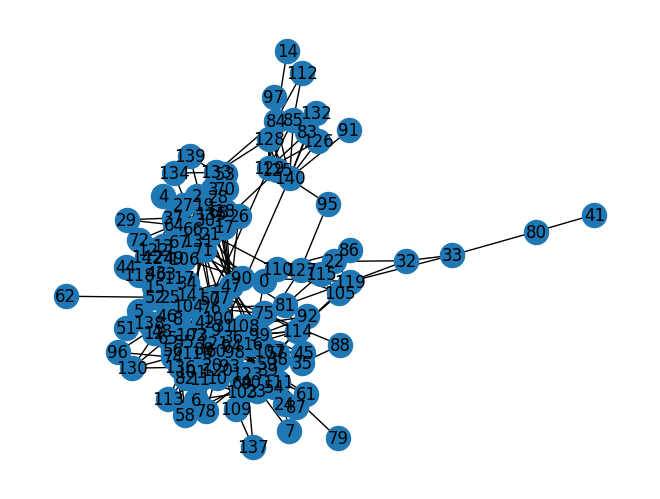

In [10]:
sel_graph = 'enron'
g = graphs[sel_graph]
nx.draw(g, with_labels=True)

# Apply graph based clustering

## Label Propagation

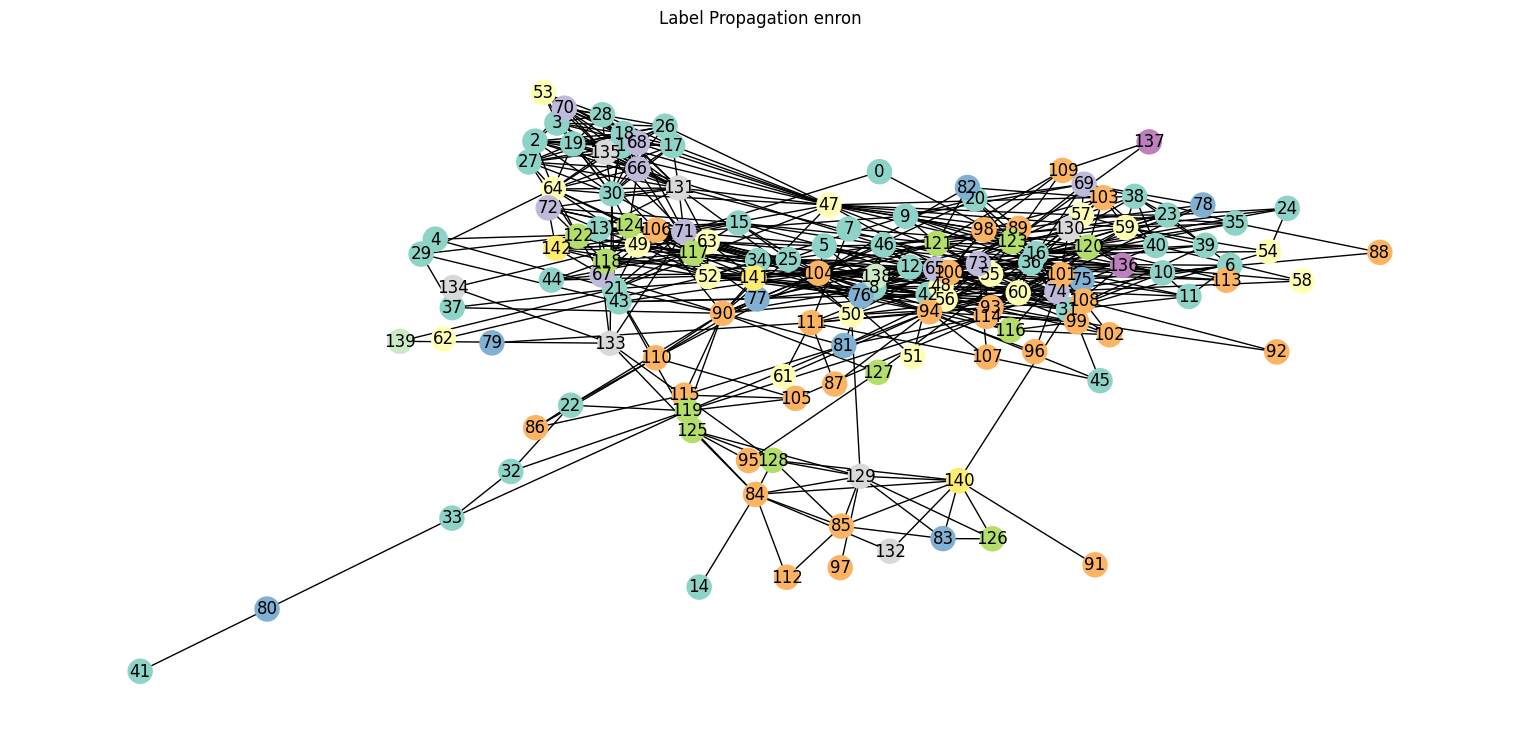

{'Number of Communities': 10,
 'Average Community Size': 14.3,
 'Modularity': 0.5052353727755463,
 'Average Cluster Coefficients': 0.4339070291479222,
 'Number of connected components': 1,
 'Coverage': 0.7303370786516854,
 'Performance': 0.8396533044420368}

In [11]:
lp_labels = label_propagation(g)

plot_communities(g, lp_labels, title=f"Label Propagation {sel_graph}")

# Calculate metrics for LP
lp_metrics = community_metrics(g, lp_labels)
lp_metrics

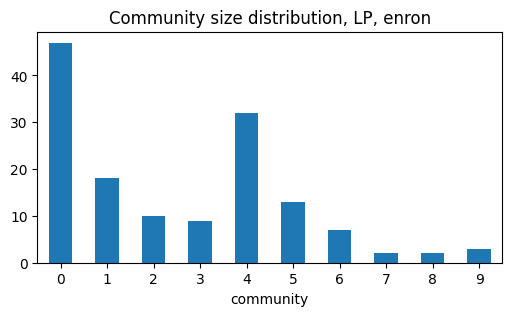

In [12]:
community_size_hist(lp_labels, title=f"Community size distribution, LP, {sel_graph}")

## Louvain

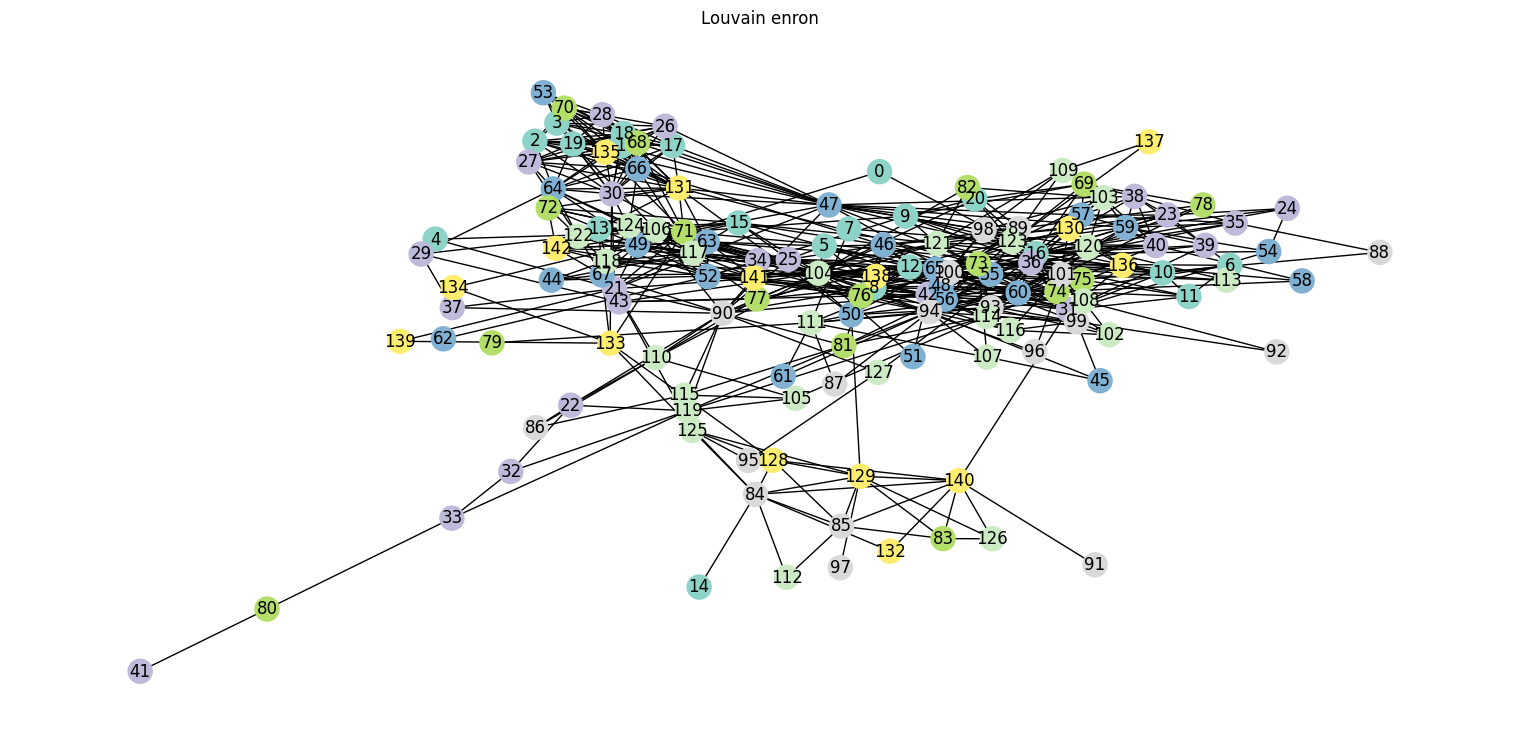

{'Number of Communities': 7,
 'Average Community Size': 20.428571428571427,
 'Modularity': 0.5678678995900847,
 'Average Cluster Coefficients': 0.4339070291479222,
 'Number of connected components': 1,
 'Coverage': 0.7335473515248796,
 'Performance': 0.886634492268295}

In [13]:
lv_labels = louvain(g)

plot_communities(g, lv_labels, title=f"Louvain {sel_graph}")

# Calculate metrics for Louvain
lv_metrics = community_metrics(g, lv_labels)
lv_metrics

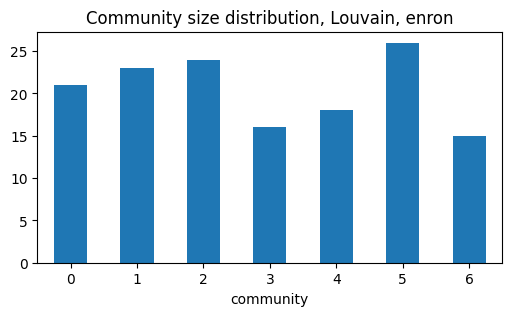

In [14]:
community_size_hist(lv_labels, title=f"Community size distribution, Louvain, {sel_graph}")

## Leiden

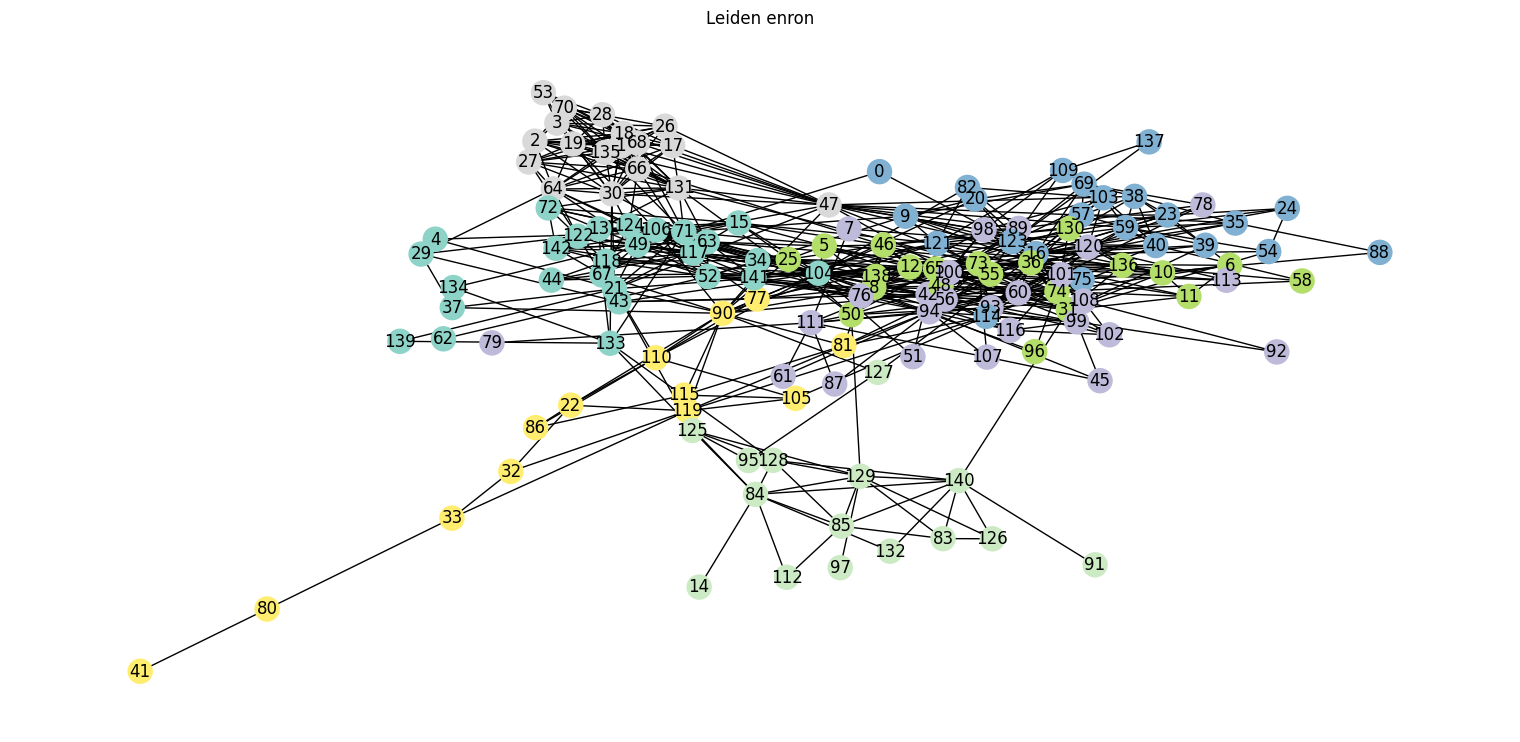

{'Number of Communities': 7,
 'Average Community Size': 20.428571428571427,
 'Modularity': 0.5668373143980481,
 'Average Cluster Coefficients': 0.4339070291479222,
 'Number of connected components': 1,
 'Coverage': 0.7351524879614767,
 'Performance': 0.8835812075248695}

In [15]:
ld_labels = leiden(g)

plot_communities(g, ld_labels, title=f"Leiden {sel_graph}")

# Calculate metrics for Leiden
ld_metrics = community_metrics(g, ld_labels)
ld_metrics

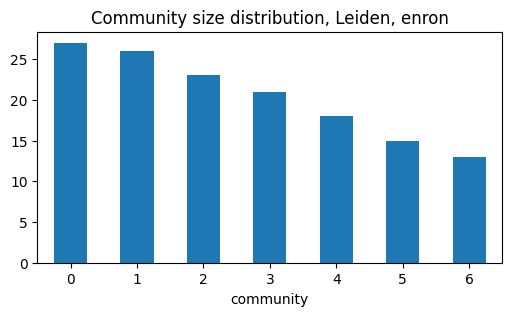

In [16]:
community_size_hist(ld_labels, title=f"Community size distribution, Leiden, {sel_graph}")

# node2vec

In [17]:
node2vec = Node2Vec(g, dimensions=32, walk_length=20, num_walks=100, workers=4) 

# Embed nodes
# Any keywords acceptable by gensim.Word2Vec can be passed, 
# `dimensions` and `workers` are automatically passed (from the Node2Vec constructor)
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=4)  

Generating walks (CPU: 4): 100%|██████████| 25/25 [00:00<00:00, 170.84it/s]


## Clustering using node2vec only

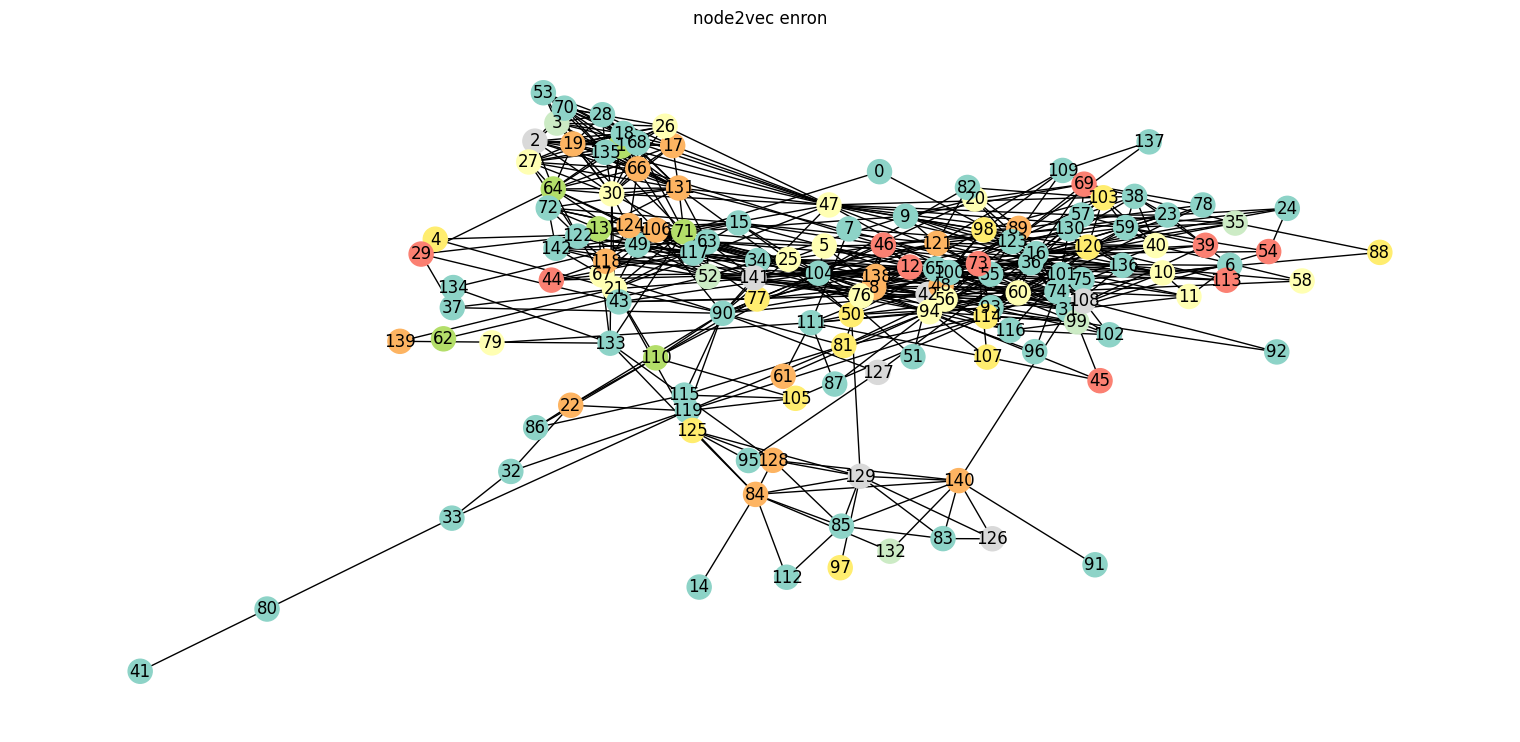

{'Number of Communities': 8,
 'Average Community Size': 17.875,
 'Modularity': -0.0023368519229431603,
 'Average Cluster Coefficients': 0.4339070291479222,
 'Number of connected components': 1,
 'Coverage': 0.2536115569823435,
 'Performance': 0.7117108243868807}

In [18]:
modularity, best_n, n2v_communities = optics(g, node2vec_model.wv.get_normed_vectors())

plot_communities(g, n2v_communities, title=f"node2vec {sel_graph}")
community_metrics(g, n2v_communities)

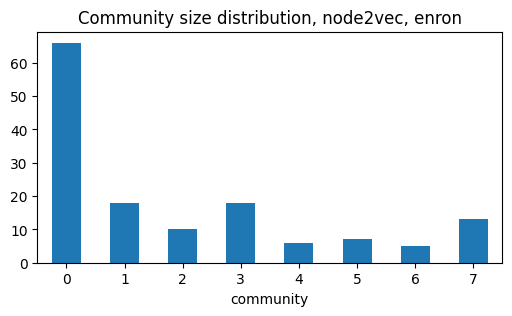

In [19]:
community_size_hist(n2v_communities, title=f"Community size distribution, node2vec, {sel_graph}")

# Apply GAT Embedding

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [21]:
# Convert networkx graph to PyTorch Geometric data object
data = from_networkx(g)

# Since the graph doesn't have node features, we use an identity matrix
data.x = torch.eye(g.number_of_nodes(), dtype=torch.float)

In [22]:
best_parameters_optuna = tune(data)
best_parameters_optuna

[I 2024-08-12 16:56:30,270] A new study created in memory with name: no-name-5de6db25-338c-4df2-8ced-768a18582b1b
[I 2024-08-12 16:56:32,055] Trial 0 finished with value: 0.5072334198166073 and parameters: {'hidden_channels': 27, 'out_channels': 30, 'heads': 8, 'learning_rate': 0.00016895208529245614, 'dropout': 0.21391722375367608, 'weight_decay': 1.803204470429122e-05}. Best is trial 0 with value: 0.5072334198166073.
[I 2024-08-12 16:56:33,327] Trial 1 finished with value: 0.21495172996606798 and parameters: {'hidden_channels': 59, 'out_channels': 13, 'heads': 3, 'learning_rate': 0.004307387887452056, 'dropout': 0.22667162982921954, 'weight_decay': 9.965989779992135e-05}. Best is trial 0 with value: 0.5072334198166073.
[I 2024-08-12 16:56:34,863] Trial 2 finished with value: 0.2514460398475764 and parameters: {'hidden_channels': 12, 'out_channels': 21, 'heads': 13, 'learning_rate': 0.0011388007069593903, 'dropout': 0.384570938055608, 'weight_decay': 2.266188397465639e-05}. Best is tr

In [23]:
best_parameters_optuna.best_value

0.5324003102061428

In [24]:
best_parameters = best_parameters_optuna.best_params

hidden_channels = best_parameters['hidden_channels']
out_channels = best_parameters['out_channels']
heads = best_parameters['heads']
dropout = best_parameters['dropout']
lr = best_parameters['learning_rate']
l2_reg = best_parameters['weight_decay']
epochs = 100
num_layers = 2

In [25]:
model = DGIModel(in_channels=data.num_features, hidden_channels=hidden_channels, out_channels=out_channels, num_layers=num_layers, heads=heads, dropout=dropout)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

def train():
    model.train()
    optimizer.zero_grad()
    pos_z, neg_z, summary = model(data)
    loss = model.dgi.loss(pos_z, neg_z, summary)
    loss.backward()
    optimizer.step()
    return loss.item()

# Training the model
for epoch in range(epochs):
    loss = train()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')

Epoch 0, Loss: 1.3894771337509155
Epoch 10, Loss: 1.379652976989746
Epoch 20, Loss: 1.361595869064331
Epoch 30, Loss: 1.363670825958252
Epoch 40, Loss: 1.345923662185669
Epoch 50, Loss: 1.3395416736602783
Epoch 60, Loss: 1.330289363861084
Epoch 70, Loss: 1.3154759407043457
Epoch 80, Loss: 1.296715259552002
Epoch 90, Loss: 1.2885401248931885


In [26]:
# Extract node embeddings
model.eval()
with torch.no_grad():
    node_embeddings = model.encoder(data.x, data.edge_index)

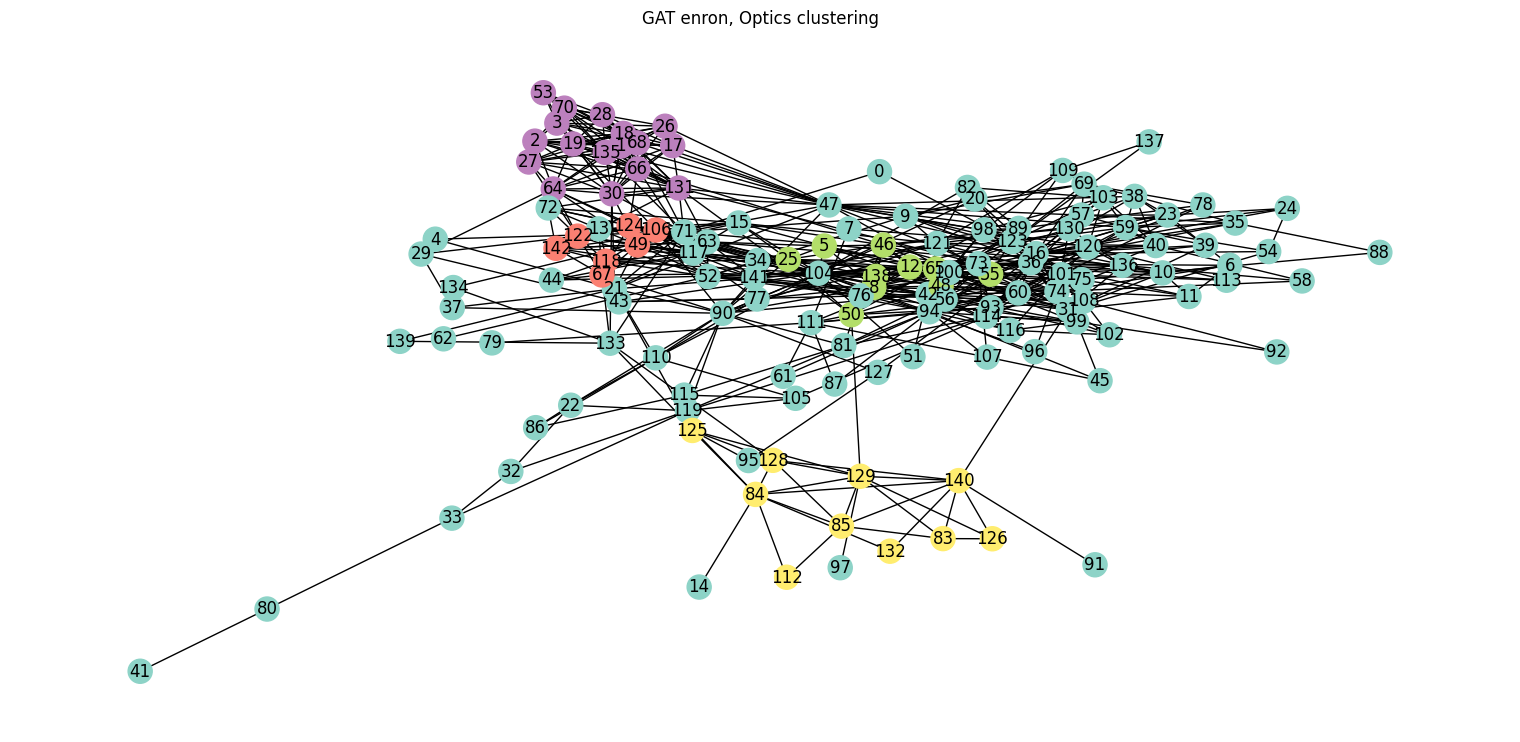

{'Number of Communities': 5,
 'Average Community Size': 28.6,
 'Modularity': 0.3692625390012083,
 'Average Cluster Coefficients': 0.4339070291479222,
 'Number of connected components': 1,
 'Coverage': 0.8009630818619583,
 'Performance': 0.5348172953806757}

In [27]:
# optics clustering
modularity, best_n, gat_communities = optics(g, node_embeddings.detach().cpu().numpy())

plot_communities(g, gat_communities, title=f"GAT {sel_graph}, Optics clustering")
community_metrics(g, gat_communities)

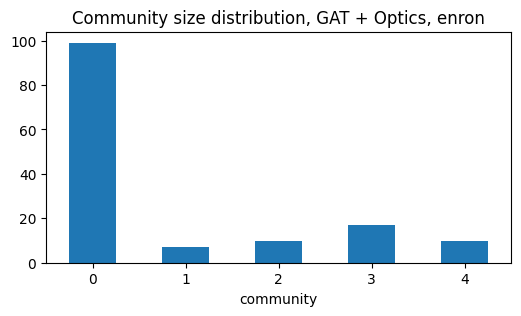

In [28]:
community_size_hist(gat_communities, title=f"Community size distribution, GAT + Optics, {sel_graph}")

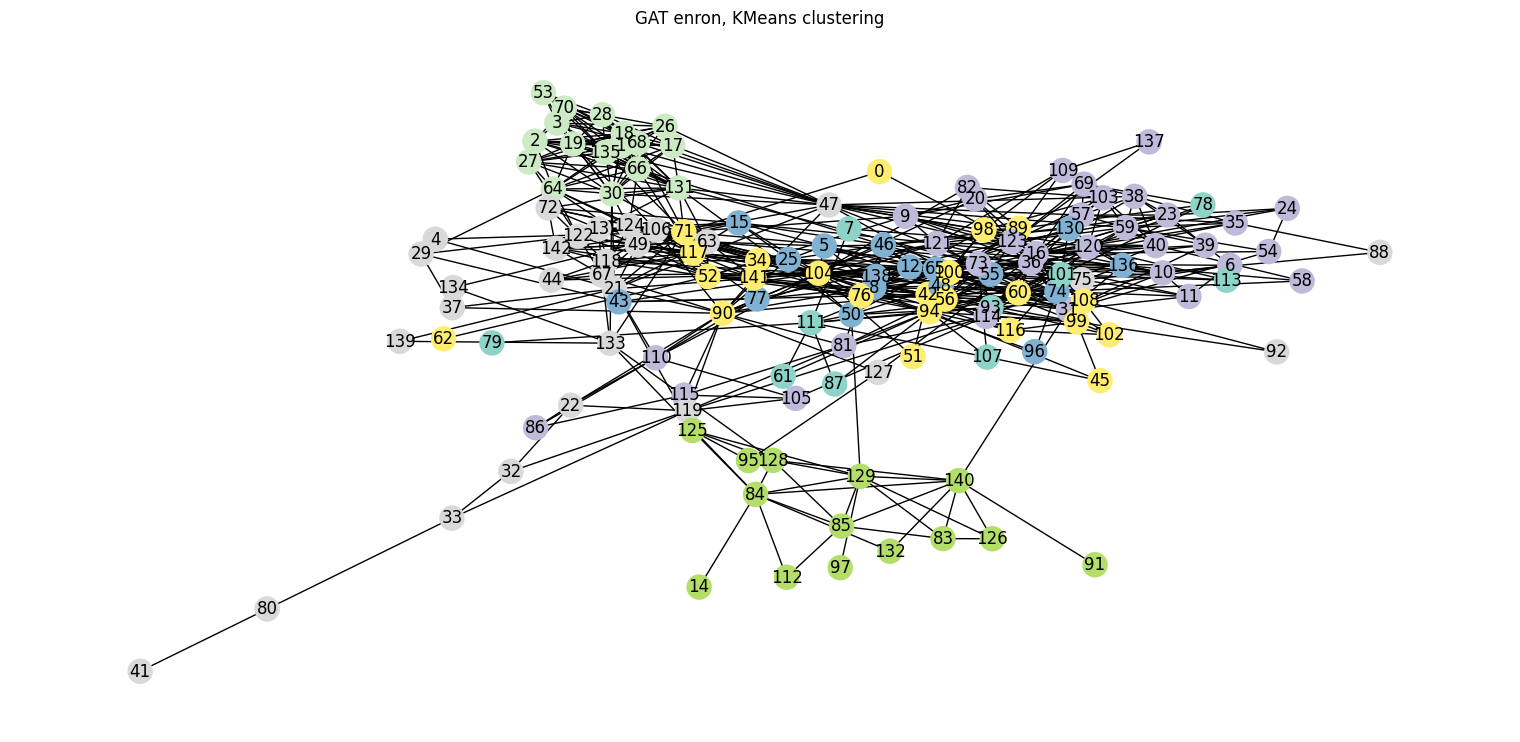

{'Number of Communities': 7,
 'Average Community Size': 20.428571428571427,
 'Modularity': 0.46676620401979757,
 'Average Cluster Coefficients': 0.4339070291479222,
 'Number of connected components': 1,
 'Coverage': 0.6452648475120385,
 'Performance': 0.8607308184772974}

In [29]:
# kmeans clustering
modularity, best_n, gat_communities = kmeans(g, node_embeddings.detach().cpu().numpy())

plot_communities(g, gat_communities, title=f"GAT {sel_graph}, KMeans clustering")
community_metrics(g, gat_communities)

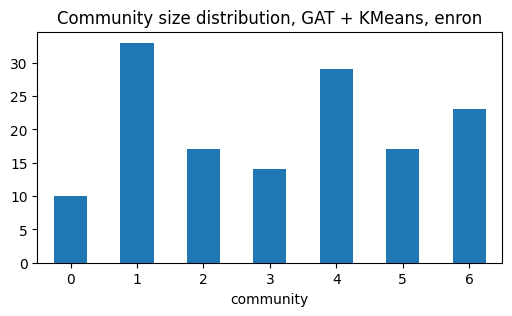

In [30]:
community_size_hist(gat_communities, title=f"Community size distribution, GAT + KMeans, {sel_graph}")

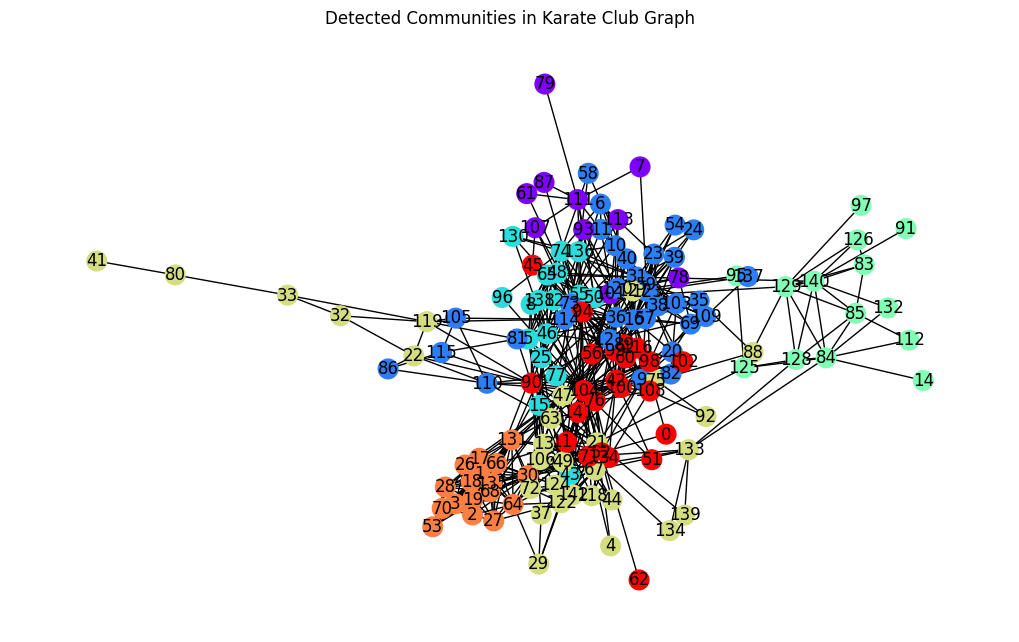

In [31]:
# Plotting the communities
plt.figure(figsize=(10, 6))
nx.draw(g, node_color=list(gat_communities.values()), with_labels=True, cmap=plt.cm.rainbow, node_size=200)
plt.title("Detected Communities in Karate Club Graph")
plt.show()